In [1]:
import pandas as pd
import numpy as np

# Load the data (assuming you are starting fresh or carrying over from notebook 1)
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\raw\Bengaluru_House_Data.csv')

print(f"Shape before dropping columns: {df.shape}")

# 1. Remove irrelevant columns
columns_to_drop = ['society', 'availability']
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Shape after dropping columns: {df_cleaned.shape}")
df_cleaned.head()

Shape before dropping columns: (13320, 9)
Shape after dropping columns: (13320, 7)


,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [2]:
# Check missing numbers before imputation
print("Missing values before numerical imputation:")
print(df_cleaned[['bath', 'balcony']].isnull().sum())

# Impute 'bath' with median (typically 2)
bath_median = df_cleaned['bath'].median()
df_cleaned['bath'] = df_cleaned['bath'].fillna(bath_median)

# Impute 'balcony' with median (typically 2)
balcony_median = df_cleaned['balcony'].median()
df_cleaned['balcony'] = df_cleaned['balcony'].fillna(balcony_median)

print("\nMissing values after numerical imputation:")
print(df_cleaned[['bath', 'balcony']].isnull().sum())

Missing values before numerical imputation:
bath        73
balcony    609
dtype: int64

Missing values after numerical imputation:
bath       0
balcony    0
dtype: int64


In [3]:
# Check missing categorical values
print("Missing values before categorical imputation:")
print(df_cleaned[['location', 'size']].isnull().sum())

# Fill missing locations with the most common location (Mode)
location_mode = df_cleaned['location'].mode()[0]
df_cleaned['location'] = df_cleaned['location'].fillna(location_mode)

# Fill missing size with the most common configuration (usually '2 BHK')
size_mode = df_cleaned['size'].mode()[0]
df_cleaned['size'] = df_cleaned['size'].fillna(size_mode)

print("\nMissing values after categorical imputation:")
print(df_cleaned[['location', 'size']].isnull().sum())

Missing values before categorical imputation:
location     1
size        16
dtype: int64

Missing values after categorical imputation:
location    0
size        0
dtype: int64


In [4]:
# Check overall remaining nulls
total_nulls = df_cleaned.isnull().sum().sum()

print(f"Total remaining null values in the entire dataset: {total_nulls}")
if total_nulls == 0:
    print("Success! Step 1 of Data Cleaning is complete.")
else:
    print("Warning: Some null values are still lurking around.")

Total remaining null values in the entire dataset: 0
Success! Step 1 of Data Cleaning is complete.


In [5]:
# Check the total number of identical duplicate entries
duplicate_count = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    # Drop duplicates, keeping the first occurrence
    df_cleaned = df_cleaned.drop_duplicates(keep='first')
    # Reset index since rows were removed
    df_cleaned = df_cleaned.reset_index(drop=True)
    print(f"Successfully removed duplicates. New dataset shape: {df_cleaned.shape}")
else:
    print("No exact duplicate entries detected.")
    

Number of duplicate rows found: 692
Successfully removed duplicates. New dataset shape: (12628, 7)


In [6]:
# Extract only the numeric digit from the 'size' string column and convert to integer
df_cleaned['bhk'] = df_cleaned['size'].apply(lambda x: int(x.split(' ')[0]))

# Verify the extraction look
df_cleaned[['size', 'bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [7]:
# Identify records where bathrooms drastically exceed bedrooms (e.g., 2 BHK with 5 bathrooms)
illogical_bathrooms = df_cleaned[df_cleaned['bath'] > df_cleaned['bhk'] + 2]

print(f"Number of logically incorrect records (excessive bathrooms): {len(illogical_bathrooms)}")
print("Examples of anomalous records being removed:")
print(illogical_bathrooms[['bhk', 'bath', 'total_sqft', 'price']].head())

# Filter our dataset to keep only realistic properties
df_cleaned = df_cleaned[df_cleaned['bath'] <= df_cleaned['bhk'] + 2].reset_index(drop=True)
print(f"\nDataset shape after removing incorrect records: {df_cleaned.shape}")

Number of logically incorrect records (excessive bathrooms): 16
Examples of anomalous records being removed:
      bhk  bath total_sqft   price
1074    9  14.0       3300   500.0
1937    8  12.0       1200   110.0
1963    8  12.0        990   120.0
2592    6   9.0      11338  1000.0
6632    5   8.0       7500  1700.0

Dataset shape after removing incorrect records: (12612, 8)


In [8]:
print("Current Cleaned Sample:")
print(df_cleaned.info())

Current Cleaned Sample:
<class 'pandas.DataFrame'>
RangeIndex: 12612 entries, 0 to 12611
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   12612 non-null  str    
 1   location    12612 non-null  str    
 2   size        12612 non-null  str    
 3   total_sqft  12612 non-null  str    
 4   bath        12612 non-null  float64
 5   balcony     12612 non-null  float64
 6   price       12612 non-null  float64
 7   bhk         12612 non-null  int64  
dtypes: float64(3), int64(1), str(4)
memory usage: 788.4 KB
None


In [9]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        # It's a range like "2100 - 2850", return the average
        return (float(tokens[0].strip()) + float(tokens[1].strip())) / 2
    try:
        # It's a normal single number string
        return float(x)
    except:
        # It's an anomaly with text units (e.g., 'Perch', 'Sq. Yards'), mark as NaN
        return None

# Apply the function to create a clean numeric column
df_cleaned['total_sqft'] = df_cleaned['total_sqft'].apply(convert_sqft_to_num)

# Drop any rows where the conversion failed (returned None)
df_cleaned = df_cleaned.dropna(subset=['total_sqft']).reset_index(drop=True)
print(f"Shape after standardizing total_sqft: {df_cleaned.shape}")

Shape after standardizing total_sqft: (12566, 8)


In [10]:
# Check for properties that violate the 300 sqft per BHK rule
impossible_area = df_cleaned[df_cleaned['total_sqft'] / df_cleaned['bhk'] < 300]
print(f"Number of impossible area records found (< 300 sqft per BHK): {len(impossible_area)}")
print("Examples of impossible configurations being removed:")
print(impossible_area[['bhk', 'total_sqft', 'price']].head())

# Filter them out
df_cleaned = df_cleaned[~(df_cleaned['total_sqft'] / df_cleaned['bhk'] < 300)].reset_index(drop=True)
print(f"\nDataset shape after removing impossible area properties: {df_cleaned.shape}")

Number of impossible area records found (< 300 sqft per BHK): 726
Examples of impossible configurations being removed:
    bhk  total_sqft  price
9     6      1020.0  370.0
45    8       600.0  200.0
58    6      1407.0  150.0
68    8      1350.0   85.0
70    3       500.0  100.0

Dataset shape after removing impossible area properties: (11840, 8)


In [11]:
# Create a temporary column to analyze price per sqft (Price is in Lakhs, so multiply by 100,000)
df_cleaned['price_per_sqft'] = (df_cleaned['price'] * 100000) / df_cleaned['total_sqft']

def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    # Group by location because a high price per sqft in a prime area is normal, but an outlier in a suburb
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        # Keep data points that are within 1 standard deviation from the mean for that location
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df_cleaned = remove_pps_outliers(df_cleaned)

# Drop the temporary price_per_sqft column to keep our feature set clean
df_cleaned = df_cleaned.drop(columns=['price_per_sqft'])
print(f"Dataset shape after treating location-based price outliers: {df_cleaned.shape}")

Dataset shape after treating location-based price outliers: (8746, 8)


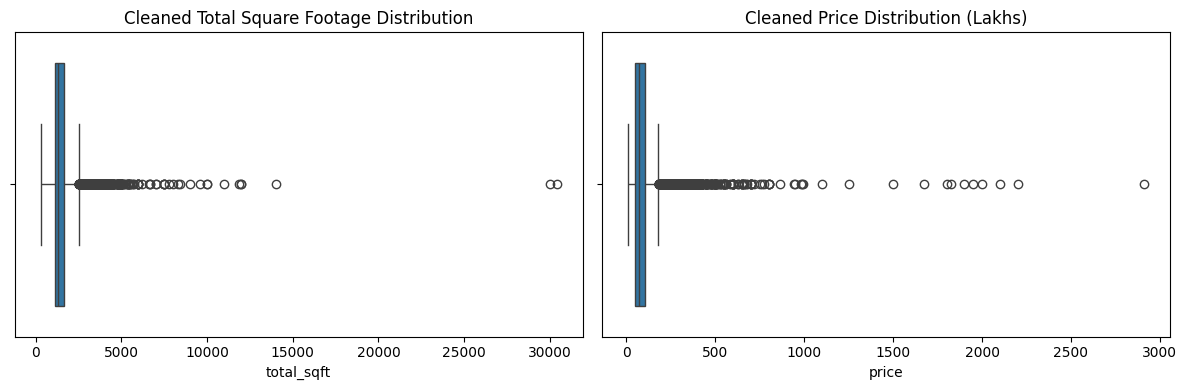

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_cleaned['total_sqft'])
plt.title('Cleaned Total Square Footage Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned['price'])
plt.title('Cleaned Price Distribution (Lakhs)')

plt.tight_layout()
plt.show()

In [13]:
# Strip accidental whitespace from text columns
df_cleaned['location'] = df_cleaned['location'].str.strip()
df_cleaned['area_type'] = df_cleaned['area_type'].str.strip()

# Replace multiple spaces with a single space inside strings
df_cleaned['area_type'] = df_cleaned['area_type'].replace(r'\s+', ' ', regex=True)
df_cleaned['location'] = df_cleaned['location'].replace(r'\s+', ' ', regex=True)

print("Standardized Unique Area Types:")
print(df_cleaned['area_type'].unique())

Standardized Unique Area Types:
<StringArray>
['Super built-up Area', 'Built-up Area', 'Plot Area', 'Carpet Area']
Length: 4, dtype: str


In [14]:
# Drop the original non-standardized text size column
if 'size' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['size'])

print("Current active columns after structural cleanup:")
print(df_cleaned.columns.tolist())

Current active columns after structural cleanup:
['area_type', 'location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk']


In [15]:
# Enforce proper numerical datatypes
df_cleaned['total_sqft'] = df_cleaned['total_sqft'].astype(float)
df_cleaned['bath'] = df_cleaned['bath'].astype(int)
df_cleaned['balcony'] = df_cleaned['balcony'].astype(int)
df_cleaned['bhk'] = df_cleaned['bhk'].astype(int)

# Quick look at data formats and descriptive stats
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 8746 entries, 0 to 8745
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   8746 non-null   str    
 1   location    8746 non-null   str    
 2   total_sqft  8746 non-null   float64
 3   bath        8746 non-null   int64  
 4   balcony     8746 non-null   int64  
 5   price       8746 non-null   float64
 6   bhk         8746 non-null   int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 478.4 KB


In [16]:
# Save the clean dataset to the 'cleaned' directory
output_path = (r'C:\Users\varsh\Downloads\Real estate prediction model\data\cleaned\bengaluru_house_data_clean.csv')
df_cleaned.to_csv(output_path, index=False)

print(f"🎉 Success! Data Cleaning Phase complete.")
print(f"Saved pristine baseline file to: {output_path}")
print(f"Final records ready for EDA & Modeling: {df_cleaned.shape[0]} rows")

🎉 Success! Data Cleaning Phase complete.
Saved pristine baseline file to: C:\Users\varsh\Downloads\Real estate prediction model\data\cleaned\bengaluru_house_data_clean.csv
Final records ready for EDA & Modeling: 8746 rows
